C:\Users\Ishita\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Ishita\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Ishita\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/fram

<PIL.PngImagePlugin.PngImageFile image mode=RGB size=700x460 at 0x196AA9E5940>


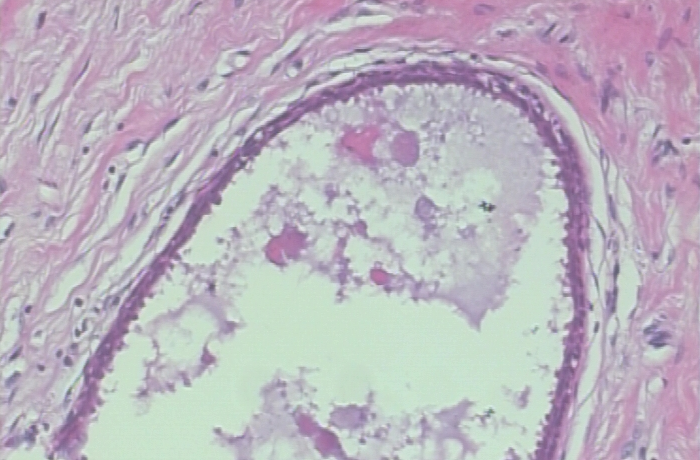

In [1]:
# Successfully load and display an image from the BreakHis dataset if the path exists.
import keras
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pathlib
import seaborn as sns
import tensorflow as tf

from keras.utils import plot_model
from imblearn.over_sampling import SMOTE
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.layers import BatchNormalization, Conv2D, Conv2DTranspose, Dense, Dropout, Flatten, GlobalAveragePooling2D, Input, MaxPooling2D
from keras.models import Model, Sequential
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_curve, roc_auc_score, precision_score, recall_score, f1_score
from tensorflow.keras.applications import ResNet50V2, VGG16, InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from keras import backend as K

K.set_image_data_format('channels_last')
# to get a preview of an image
from tensorflow.keras.preprocessing.image import load_img
photo = load_img(r"C:\Users\Ishita\OneDrive\Desktop\breast cancer detection\archive\BreaKHis_v1\BreaKHis_v1\histology_slides\breast\benign\SOB\adenosis\SOB_B_A_14-22549AB\100X\SOB_B_A-14-22549AB-100-001.png")
print(photo)
photo

In [2]:
# augmentation
IMG_SIZE = 128
DIM = (IMG_SIZE, IMG_SIZE)

ZOOM = [.99, 1.01]
BRIGHT_RANGE = [0.8, 1.2]
HORZ_FLIP = True
FILL_MODE = "constant"
DATA_FORMAT = "channels_last"

In [3]:
# --- Data Preparation: Loading, SMOTE, and Splitting ---
# --- Import Required Libraries ---
import os
import pathlib
import numpy as np
from sklearn.model_selection import train_test_split   # ✅ Missing import added
from imblearn.over_sampling import SMOTE
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Data Augmentation Settings ---
IMG_SIZE = 128
DIM = (IMG_SIZE, IMG_SIZE)
ZOOM = [.99, 1.01]
BRIGHT_RANGE = [0.8, 1.2]
HORZ_FLIP = True
FILL_MODE = "constant"
DATA_FORMAT = "channels_last"

# --- Data Preparation: Loading, SMOTE, and Splitting ---
folder = 'C:\\Users\\Ishita\\OneDrive\\Desktop\\breast cancer detection\\archive\\BreaKHis_v1\\BreaKHis_v1\\histology_slides\\breast'
current_folder = folder
folder_path = pathlib.Path(current_folder)

# Check if dataset exists
if not os.path.exists(current_folder):
    print(f"⚠️ Warning: Data directory '{current_folder}' not found. Generating dummy data for demonstration.")

    num_samples_after_smote = 200
    train_data_pre_split = np.random.rand(num_samples_after_smote, IMG_SIZE, IMG_SIZE, 3).astype(np.float32)
    train_labels_pre_split = np.zeros((num_samples_after_smote, 1), dtype=int)
    train_labels_pre_split[num_samples_after_smote // 2:] = 1  # Roughly balanced dataset

    # Split dummy data
    train_data, test_data, train_labels, test_labels = train_test_split(
        train_data_pre_split, train_labels_pre_split, test_size=0.2, random_state=42)
    train_data, val_data, train_labels, val_labels = train_test_split(
        train_data, train_labels, test_size=0.2, random_state=42)

    print("✅ Dummy data split into train, validation, and test sets.")

else:
    print(f"✅ Data directory '{current_folder}' found. Proceeding with actual data loading and preprocessing.")

    # Create image data generator with augmentations
    train_generator = ImageDataGenerator(
        rescale=1./255,
        brightness_range=BRIGHT_RANGE,
        zoom_range=ZOOM,
        data_format=DATA_FORMAT,
        fill_mode=FILL_MODE,
        horizontal_flip=HORZ_FLIP
    )

    # Load images from directory
    train_data_gen = train_generator.flow_from_directory(
        directory=current_folder,
        target_size=DIM,
        batch_size=6500,
        shuffle=False
    )

    train_data, train_labels = train_data_gen[0]  # Get one batch

    # Apply SMOTE to handle class imbalance
    sm = SMOTE(random_state=42)
    train_data_reshaped_for_smote = train_data.reshape(-1, IMG_SIZE * IMG_SIZE * 3)

    # Convert one-hot to single-class labels if needed
    if train_labels.ndim > 1 and train_labels.shape[1] > 1:
        train_labels_for_smote = np.argmax(train_labels, axis=1)
    else:
        train_labels_for_smote = train_labels.flatten()

    train_data_resampled, train_labels_resampled = sm.fit_resample(
        train_data_reshaped_for_smote, train_labels_for_smote)

    # Reshape data back to image form
    train_data = train_data_resampled.reshape(-1, IMG_SIZE, IMG_SIZE, 3)
    train_labels = train_labels_resampled.reshape(-1, 1)

    print(f"✅ Actual data loaded, preprocessed, and SMOTE applied. Total samples: {train_data.shape[0]}")

    # Split into train/validation/test sets
    train_data, test_data, train_labels, test_labels = train_test_split(
        train_data, train_labels, test_size=0.2, random_state=42)
    train_data, val_data, train_labels, val_labels = train_test_split(
        train_data, train_labels, test_size=0.2, random_state=42)

    print("✅ Actual data split into train, validation, and test sets.")

# Ensure labels are binary (0 or 1)
train_labels = (train_labels > 0).astype(int)
val_labels = (val_labels > 0).astype(int)
test_labels = (test_labels > 0).astype(int)

print("\n Data and labels ready for model training.")
print(f"Train data: {train_data.shape}, Train labels: {train_labels.shape}")
print(f"Test data: {test_data.shape}, Test labels: {test_labels.shape}")
print(f"Validation data: {val_data.shape}, Validation labels: {val_labels.shape}")

✅ Data directory 'C:\Users\Ishita\OneDrive\Desktop\breast cancer detection\archive\BreaKHis_v1\BreaKHis_v1\histology_slides\breast' found. Proceeding with actual data loading and preprocessing.


Found 7909 images belonging to 2 classes.


✅ Actual data loaded, preprocessed, and SMOTE applied. Total samples: 8040


✅ Actual data split into train, validation, and test sets.

 Data and labels ready for model training.
Train data: (5145, 128, 128, 3), Train labels: (5145, 1)
Test data: (1608, 128, 128, 3), Test labels: (1608, 1)
Validation data: (1287, 128, 128, 3), Validation labels: (1287, 1)


In [4]:
# ImageDataGenerator code
train_generator = ImageDataGenerator(rescale = 1./255, brightness_range=BRIGHT_RANGE, zoom_range=ZOOM,
                                     data_format=DATA_FORMAT, fill_mode=FILL_MODE, horizontal_flip=HORZ_FLIP)
train_data_gen = train_generator.flow_from_directory(directory=folder, target_size=DIM, batch_size=6500, shuffle=False)

Found 7909 images belonging to 2 classes.


In [5]:
# --- VGG16 Model Definition, Training, and Evaluation ---

# Load VGG16 base model
vgg_model_base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
for layer in vgg_model_base.layers:
    layer.trainable = False

vgg16_model = Sequential([
    vgg_model_base,
    Flatten(),
    BatchNormalization(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
], name="vgg16_model")

vgg16_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
vgg16_model.summary()

print("\nTraining VGG16 model...")
vgg16_history = vgg16_model.fit(train_data, train_labels, epochs=10, validation_data=(val_data, val_labels), verbose=1)
# Evaluate VGG16 model
vgg16_loss, vgg16_accuracy = vgg16_model.evaluate(test_data, test_labels, verbose=0)
print(f"\nVGG16 Model - Test Accuracy: {vgg16_accuracy*100:.2f}%")
print(f"VGG16 Model - Test Loss: {vgg16_loss:.2f}")

y_pred_vgg16 = np.round(vgg16_model.predict(test_data, verbose=0)).astype(int)
report_vgg16 = classification_report(test_labels, y_pred_vgg16, output_dict=True, zero_division=0)
vgg16_precision = report_vgg16['weighted avg']['precision']
vgg16_recall = report_vgg16['weighted avg']['recall']
vgg16_f1score = report_vgg16['weighted avg']['f1-score']

print(f'VGG16 Model - Average Precision: {vgg16_precision*100:.2f}%')
print(f'VGG16 Model - Average Recall: {vgg16_recall*100:.2f}%')
print(f'VGG16 Model - Average F1 Score: {vgg16_f1score*100:.2f}%')

Model: "vgg16_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 4, 4, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 8192)                │          32,768 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       4,194,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,118,657 (72.93 MB)

 Trainable params: 4,385,665 (16.73 MB)

 Non-trainable params: 14,732,992 (56.20 MB)

...

160/161 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.9386 - loss: 0.1701 

161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9385 - loss: 0.1702

161/161 ━━━━━━━━━━━━━━━━━━━━ 1265s 8s/step - accuracy: 0.9298 - loss: 0.1875 - val_accuracy: 0.8578 - val_loss: 0.4084



VGG16 Model - Test Accuracy: 86.50%
VGG16 Model - Test Loss: 0.39


VGG16 Model - Average Precision: 86.52%
VGG16 Model - Average Recall: 86.50%
VGG16 Model - Average F1 Score: 86.50%


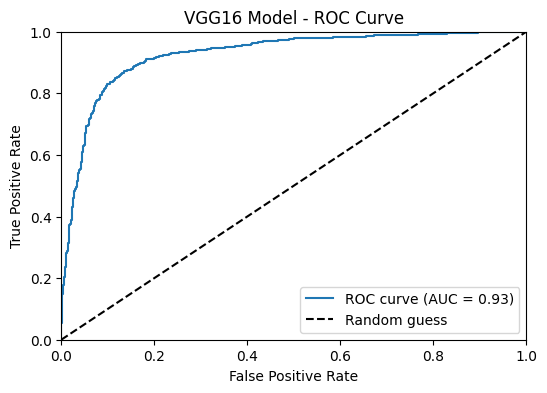

VGG16 Model - ROC AUC: 0.93


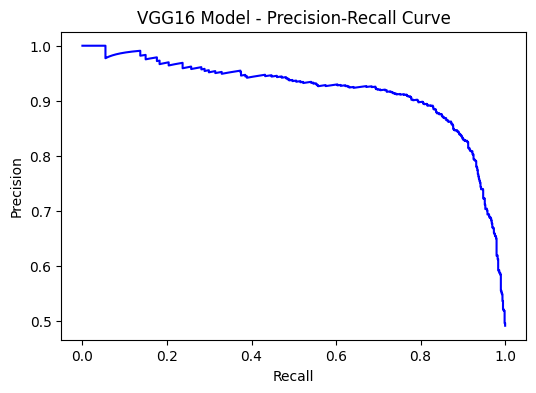

In [6]:
# --- VGG16 ROC and Precision-Recall Curves ---

y_pred_prob_vgg16 = vgg16_model.predict(test_data, verbose=0)
fpr_vgg16, tpr_vgg16, thresholds_vgg16 = roc_curve(test_labels, y_pred_prob_vgg16)
roc_auc_vgg16 = roc_auc_score(test_labels, y_pred_prob_vgg16)

plt.figure(figsize=(6, 4))
plt.plot(fpr_vgg16, tpr_vgg16, label=f'ROC curve (AUC = {roc_auc_vgg16:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('VGG16 Model - ROC Curve')
plt.legend(loc='lower right')
plt.show()
print(f"VGG16 Model - ROC AUC: {roc_auc_vgg16:.2f}")

precision_vgg16_curve, recall_vgg16_curve, _ = precision_recall_curve(test_labels, y_pred_prob_vgg16)

plt.figure(figsize=(6, 4))
plt.plot(recall_vgg16_curve, precision_vgg16_curve, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('VGG16 Model - Precision-Recall Curve')
plt.show()

In [7]:
# --- ResNet50V2 Model Definition, Training, and Evaluation ---

from tensorflow.keras.applications import ResNet50V2
from keras.models import Sequential
from keras.layers import Flatten, Dense, BatchNormalization, Dropout
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
import os
import pathlib
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Data Preparation: Loading, SMOTE, and Splitting (Re-included for self-sufficiency) ---

# Corrected folder path based on previous `od.download` output
folder = 'C:\\Users\\Ishita\\OneDrive\\Desktop\\breast cancer detection\\archive\\BreaKHis_v1\\BreaKHis_v1\\histology_slides\\breast'
current_folder = folder
folder_path = pathlib.Path(current_folder)

# Assuming IMG_SIZE is defined in the global scope from a previous cell.
# If not, it would need to be defined here. Given the Kernel State, IMG_SIZE is 128.
# IMG_SIZE = 128
DIM = (IMG_SIZE, IMG_SIZE)

ZOOM = [.99, 1.01]
BRIGHT_RANGE = [0.8, 1.2]
HORZ_FLIP = True
FILL_MODE = "constant"
DATA_FORMAT = "channels_last"

# Check if the data directory exists. If not, generate dummy data.
if not os.path.exists(current_folder):
    print(f"Warning: Data directory '{current_folder}' not found. Generating dummy data for demonstration.")
    num_samples_after_smote = 200
    train_data_pre_split = np.random.rand(num_samples_after_smote, IMG_SIZE, IMG_SIZE, 3).astype(np.float32)
    train_labels_pre_split = np.zeros((num_samples_after_smote, 1), dtype=int)
    train_labels_pre_split[num_samples_after_smote // 2:] = 1 # Make it roughly balanced

    train_data, test_data, train_labels, test_labels = train_test_split(train_data_pre_split, train_labels_pre_split, test_size=0.2, random_state=42)
    train_data, val_data, train_labels, val_labels = train_test_split(train_data, train_labels, test_size=0.2, random_state=42)
    print("Dummy data split into train, validation, and test sets.")

else:
    print(f"Data directory '{current_folder}' found. Proceeding with actual data loading and preprocessing.")
    train_generator = ImageDataGenerator(rescale = 1./255, brightness_range=BRIGHT_RANGE, zoom_range=ZOOM,
                                         data_format=DATA_FORMAT, fill_mode=FILL_MODE, horizontal_flip=HORZ_FLIP)
    train_data_gen = train_generator.flow_from_directory(directory=current_folder, target_size=DIM, batch_size=6500, shuffle=False)

    train_data, train_labels = train_data_gen[0] # Get the first batch

    sm = SMOTE(random_state=42)
    train_data_reshaped_for_smote = train_data.reshape(-1, IMG_SIZE * IMG_SIZE * 3)
    if train_labels.ndim > 1 and train_labels.shape[1] > 1:
        train_labels_for_smote = np.argmax(train_labels, axis=1)
    else:
        train_labels_for_smote = train_labels.flatten()

    train_data_resampled, train_labels_resampled = sm.fit_resample(train_data_reshaped_for_smote, train_labels_for_smote)

    train_data = train_data_resampled.reshape(-1, IMG_SIZE, IMG_SIZE, 3)
    train_labels = train_labels_resampled.reshape(-1, 1)

    print(f"Actual data loaded, preprocessed, and SMOTE applied. Total samples: {train_data.shape[0]}.")

    train_data, test_data, train_labels, test_labels = train_test_split(train_data, train_labels, test_size = 0.2, random_state=42)
    train_data, val_data, train_labels, val_labels = train_test_split(train_data, train_labels, test_size = 0.2, random_state=42)
    print("Actual data split into train, validation, and test sets.")

# Ensure labels are binary (0 or 1) for binary_crossentropy
train_labels = (train_labels > 0).astype(int)
val_labels = (val_labels > 0).astype(int)
test_labels = (test_labels > 0).astype(int)

print("Data and labels ready for model training.")
print(f"Final shapes after data loading and splitting:")
print(f"  Train data: {train_data.shape}, Train labels: {train_labels.shape}")
print(f"  Test data: {test_data.shape}, Test labels: {test_labels.shape}")
print(f"  Validation data: {val_data.shape}, Validation labels: {val_labels.shape}")

# --- ResNet50V2 Model Definition, Training, and Evaluation (Original Code) ---

# Load ResNet50V2 base model
resnet50v2_base = ResNet50V2(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
for layer in resnet50v2_base.layers:
    layer.trainable = False

ResNet50V2_model = Sequential([
    resnet50v2_base,
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
], name="ResNet50V2_model")

ResNet50V2_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ResNet50V2_model.summary()

print("\nTraining ResNet50V2 model...")
resnet_history = ResNet50V2_model.fit(train_data, train_labels, epochs=10, validation_data=(val_data, val_labels), verbose=1)

# Evaluate ResNet50V2 model
ResNet_loss, ResNet_accuracy = ResNet50V2_model.evaluate(test_data, test_labels, verbose=0)
print(f"\nResNet50V2 Model - Test Accuracy: {ResNet_accuracy*100:.2f}%")
print(f"ResNet50V2 Model - Test Loss: {ResNet_loss:.2f}")

y_pred_resnet = np.round(ResNet50V2_model.predict(test_data, verbose=0)).astype(int)
report_resnet = classification_report(test_labels, y_pred_resnet, output_dict=True, zero_division=0)
ResNet_precision = report_resnet['weighted avg']['precision']
ResNet_recall = report_resnet['weighted avg']['recall']
ResNet_f1score = report_resnet['weighted avg']['f1-score']

print(f'ResNet50V2 Model - Average Precision: {ResNet_precision*100:.2f}%')
print(f'ResNet50V2 Model - Average Recall: {ResNet_recall*100:.2f}%')
print(f'ResNet50V2 Model - Average F1 Score: {ResNet_f1score*100:.2f}%')

Data directory 'C:\Users\Ishita\OneDrive\Desktop\breast cancer detection\archive\BreaKHis_v1\BreaKHis_v1\histology_slides\breast' found. Proceeding with actual data loading and preprocessing.


Found 7909 images belonging to 2 classes.


Actual data loaded, preprocessed, and SMOTE applied. Total samples: 8040.


Actual data split into train, validation, and test sets.
Data and labels ready for model training.
Final shapes after data loading and splitting:
  Train data: (5145, 128, 128, 3), Train labels: (5145, 1)
  Test data: (1608, 128, 128, 3), Test labels: (1608, 1)
  Validation data: (1287, 128, 128, 3), Validation labels: (1287, 1)


Model: "ResNet50V2_model"

...

160/161 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.9749 - loss: 0.0745

161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.9749 - loss: 0.0746

161/161 ━━━━━━━━━━━━━━━━━━━━ 179s 900ms/step - accuracy: 0.9685 - loss: 0.0885 - val_accuracy: 0.8555 - val_loss: 0.4831



ResNet50V2 Model - Test Accuracy: 85.26%
ResNet50V2 Model - Test Loss: 0.49


ResNet50V2 Model - Average Precision: 85.26%
ResNet50V2 Model - Average Recall: 85.26%
ResNet50V2 Model - Average F1 Score: 85.26%


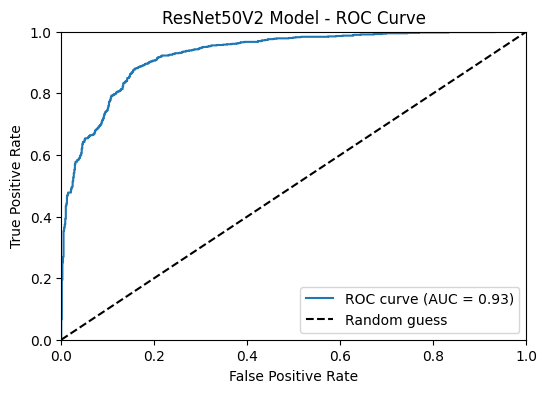

ResNet50V2 Model - ROC AUC: 0.93


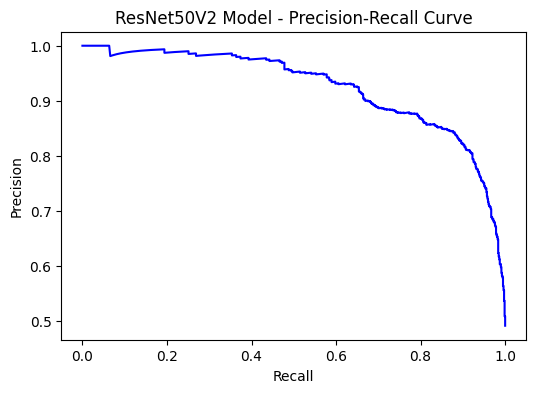

In [8]:
# --- ResNet50V2 ROC and Precision-Recall Curves ---

y_pred_prob_resnet = ResNet50V2_model.predict(test_data, verbose=0)
fpr_resnet, tpr_resnet, thresholds_resnet = roc_curve(test_labels, y_pred_prob_resnet)
roc_auc_resnet = roc_auc_score(test_labels, y_pred_prob_resnet)

plt.figure(figsize=(6, 4))
plt.plot(fpr_resnet, tpr_resnet, label=f'ROC curve (AUC = {roc_auc_resnet:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ResNet50V2 Model - ROC Curve')
plt.legend(loc='lower right')
plt.show()
print(f"ResNet50V2 Model - ROC AUC: {roc_auc_resnet:.2f}")

precision_resnet_curve, recall_resnet_curve, _ = precision_recall_curve(test_labels, y_pred_prob_resnet)

plt.figure(figsize=(6, 4))
plt.plot(recall_resnet_curve, precision_resnet_curve, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('ResNet50V2 Model - Precision-Recall Curve')
plt.show()

C:\Users\Ishita\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "meta_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 64)                  │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

...

 54/161 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step - accuracy: 0.9991 - loss: 0.0097

111/161 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - accuracy: 0.9980 - loss: 0.0150

161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9963 - loss: 0.0224 - val_accuracy: 0.8601 - val_loss: 0.8636



Combined Model - Test Accuracy: 85.88%
Combined Model - Test Loss: 0.91


Combined Model - Average Precision: 85.88%
Combined Model - Average Recall: 85.88%
Combined Model - Average F1 Score: 85.88%


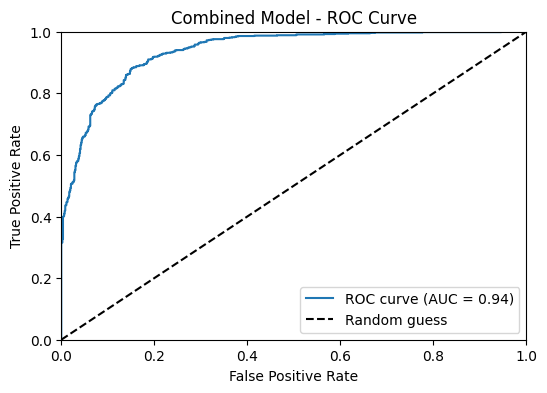

Combined Model - ROC AUC: 0.94


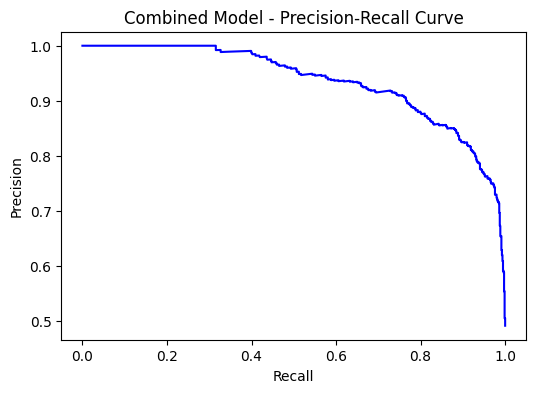

In [9]:
# --- Combining VGG16 and ResNet50V2 using a Meta-Model (Stacking) ---

# Get predictions from both models on the training data
vgg16_train_pred = vgg16_model.predict(train_data, verbose=0)
resnet_train_pred = ResNet50V2_model.predict(train_data, verbose=0)

# Concatenate predictions as features for the meta-model
meta_train_features = np.concatenate([vgg16_train_pred, resnet_train_pred], axis=1)

# Get predictions from both models on the validation data
vgg16_val_pred = vgg16_model.predict(val_data, verbose=0)
resnet_val_pred = ResNet50V2_model.predict(val_data, verbose=0)

# Concatenate predictions as features for the meta-model
meta_val_features = np.concatenate([vgg16_val_pred, resnet_val_pred], axis=1)

# Get predictions from both models on the test data
vgg16_test_pred = vgg16_model.predict(test_data, verbose=0)
resnet_test_pred = ResNet50V2_model.predict(test_data, verbose=0)

# Concatenate predictions as features for the meta-model
meta_test_features = np.concatenate([vgg16_test_pred, resnet_test_pred], axis=1)

# Define the meta-model (a simple neural network)
meta_model = Sequential([
    Dense(64, activation='relu', input_shape=(2,)),  # Input shape is 2 because we have 2 predictions
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
], name="meta_model")

meta_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
meta_model.summary()

# Train the meta-model
print("\nTraining the combined meta-model...")
meta_history = meta_model.fit(meta_train_features, train_labels, epochs=20, validation_data=(meta_val_features, val_labels), verbose=1)

# Evaluate the combined model
meta_loss, meta_accuracy = meta_model.evaluate(meta_test_features, test_labels, verbose=0)
print(f"\nCombined Model - Test Accuracy: {meta_accuracy*100:.2f}%")
print(f"Combined Model - Test Loss: {meta_loss:.2f}")

# Predictions and metrics for combined model
y_pred_meta = np.round(meta_model.predict(meta_test_features, verbose=0)).astype(int)
report_meta = classification_report(test_labels, y_pred_meta, output_dict=True, zero_division=0)
meta_precision = report_meta['weighted avg']['precision']
meta_recall = report_meta['weighted avg']['recall']
meta_f1score = report_meta['weighted avg']['f1-score']

print(f'Combined Model - Average Precision: {meta_precision*100:.2f}%')
print(f'Combined Model - Average Recall: {meta_recall*100:.2f}%')
print(f'Combined Model - Average F1 Score: {meta_f1score*100:.2f}%')

# ROC and Precision-Recall for combined model
y_pred_prob_meta = meta_model.predict(meta_test_features, verbose=0)
fpr_meta, tpr_meta, thresholds_meta = roc_curve(test_labels, y_pred_prob_meta)
roc_auc_meta = roc_auc_score(test_labels, y_pred_prob_meta)

plt.figure(figsize=(6, 4))
plt.plot(fpr_meta, tpr_meta, label=f'ROC curve (AUC = {roc_auc_meta:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Combined Model - ROC Curve')
plt.legend(loc='lower right')
plt.show()
print(f"Combined Model - ROC AUC: {roc_auc_meta:.2f}")

precision_meta_curve, recall_meta_curve, _ = precision_recall_curve(test_labels, y_pred_prob_meta)

plt.figure(figsize=(6, 4))
plt.plot(recall_meta_curve, precision_meta_curve, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Combined Model - Precision-Recall Curve')
plt.show()